In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [23]:
def SIR_Fast(u, t, N, gamma, R0):
    S, I, R = u
    beta = R0 * gamma / N
    dS = - beta * S * I
    dI = beta * S * I - gamma * I
    dR = gamma * I 
    return [dS, dI, dR]

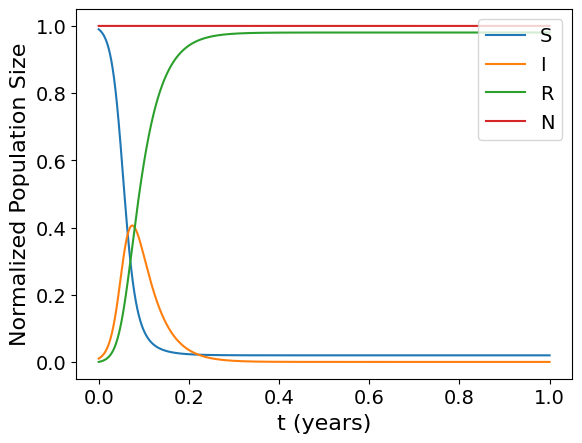

In [25]:
N = 1
R0 = 4
gamma = 1/2
    
u = odeint(SIR_Fast, [.99, .01, 0], t, args=(N, gamma, R0))

fig, ax = plt.subplots()
ax.plot(t/52., u[:,0], color='C0', label="S")
ax.plot(t/52., u[:,1], color='C1', label="I")
ax.plot(t/52., u[:,2], color='C2', label="R")
ax.plot(t/52., np.sum(u, axis=1), color='C3', label="N")

ax.legend(fontsize=14, loc="upper right")
ax.set_xlabel("t (years)", fontsize=16)
ax.set_ylabel("Normalized Population Size", fontsize=16)
ax.tick_params(axis='both', labelsize=14)


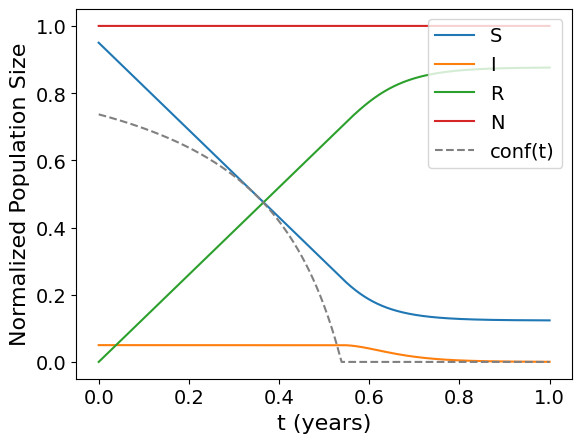

In [ ]:
def SIR_Fast_Opt(u, t, N, gamma, R0):
    S, I, R = u
    beta = (1 - conf(S,N,R0)) * R0 * gamma / N
    dS = - beta * S * I
    dI = beta * S * I - gamma * I
    dR = gamma * I 
    return [dS, dI, dR]

def conf(S, N, R0):
    if S > N/R0:
        return 1 - N/(R0*S)
    else:
        return 0.0

N = 1
R0 = 4
gamma = 1/2
    
t = np.linspace(0, 52, 20001)
    
u = odeint(SIR_Fast_Opt, [.95, .05, 0], t, args=(N, gamma, R0))

fig, ax = plt.subplots()
ax.plot(t/52., u[:,0], color='C0', label="S")
ax.plot(t/52., u[:,1], color='C1', label="I")
ax.plot(t/52., u[:,2], color='C2', label="R")
ax.plot(t/52., np.sum(u, axis=1), color='C3', label="N")

c = np.zeros_like(t)
for i, tt in enumerate(t):
    c[i] = conf(u[i,0], N, R0)
ax.plot(t/52, c, color='gray', linestyle='--', label="conf(t)")

ax.legend(fontsize=14, loc="upper right")
ax.set_xlabel("t (years)", fontsize=16)
ax.set_ylabel("Normalized Population Size", fontsize=16)
ax.tick_params(axis='both', labelsize=14)


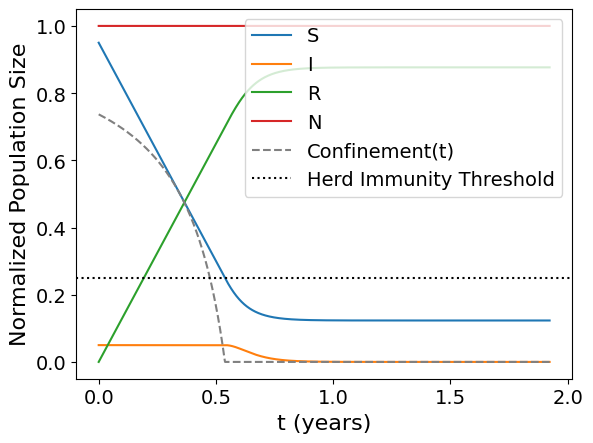

In [53]:
def SIR_Fast_Opt(u, t, N, gamma, R0):
    S, I, R = u
    beta = (1 - conf(S,N,R0)) * R0 * gamma / N
    dS = - beta * S * I
    dI = beta * S * I - gamma * I
    dR = gamma * I 
    return [dS, dI, dR]

def conf(S, N, R0):
    if S > N/R0:
        return 1- N/R0/S
    else:
        return 0.0

N = 1
R0 = 4
gamma = 1/2
    
t = np.linspace(0, 100, 20001)
    
u = odeint(SIR_Fast_Opt, [.95, .05, 0], t, args=(N, gamma, R0))

fig, ax = plt.subplots()
ax.plot(t/52., u[:,0], color='C0', label="S")
ax.plot(t/52., u[:,1], color='C1', label="I")
ax.plot(t/52., u[:,2], color='C2', label="R")
ax.plot(t/52., np.sum(u, axis=1), color='C3', label="N")

c = np.zeros_like(t)
for i, tt in enumerate(t):
    c[i] = conf(u[i,0], N, R0)
ax.plot(t/52, c, color='gray', linestyle='--', label="Confinement(t)")
ax.axhline(N/R0, color='black', linestyle=':', label="Herd Immunity Threshold")

ax.legend(fontsize=14, loc="upper right")
ax.set_xlabel("t (years)", fontsize=16)
ax.set_ylabel("Normalized Population Size", fontsize=16)
ax.tick_params(axis='both', labelsize=14)
